In [75]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder,RobustScaler
from sklearn.metrics import classification_report,r2_score,root_mean_squared_error,mean_absolute_error,mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsRegressor

In [39]:
df=pd.read_csv('customer_behavior_dataset.csv')

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 1000 non-null   int64  
 1   Age                        1000 non-null   int64  
 2   Gender                     970 non-null    object 
 3   Membership                 533 non-null    object 
 4   Annual_Income_kUSD         1000 non-null   float64
 5   Region                     1000 non-null   object 
 6   Platform                   1000 non-null   object 
 7   Product_Preference         1000 non-null   object 
 8   Visits_per_Month           1000 non-null   int64  
 9   Time_Spent_per_Visit_min   940 non-null    float64
 10  Pages_Visited_per_Session  1000 non-null   int64  
 11  Previous_Purchases         1000 non-null   int64  
 12  Avg_Purchase_Value_USD     960 non-null    float64
 13  Total_Purchase_Value_USD   1000 non-null   float6

In [41]:
df.head()

,CustomerID,Age,Gender,Membership,Annual_Income_kUSD,Region,Platform,Product_Preference,Visits_per_Month,Time_Spent_per_Visit_min,Pages_Visited_per_Session,Previous_Purchases,Avg_Purchase_Value_USD,Total_Purchase_Value_USD,Days_Since_Last_Purchase,Made_Purchase_Last_Month,Will_Purchase_Next_Month,Next_Month_Spend_USD
0,1,40,Male,NaN,40.58,Central,Mobile,Apparel,5,6.0,5,1,NaN,42.43,0,0,0,0.0
1,2,33,Male,NaN,53.20,West,Mobile,Apparel,3,9.0,2,0,25.95,0.00,206,0,0,0.0
2,3,42,Female,NaN,73.70,West,Mobile,Home & Kitchen,3,13.9,2,0,71.06,13.92,15,0,0,0.0
3,4,51,Female,NaN,45.95,East,Mobile,Sports,3,1.0,4,1,35.81,91.43,149,0,0,0.0
4,5,32,Male,Premium,45.32,East,Mobile,Apparel,11,11.1,7,3,5.00,37.75,6,1,0,0.0


In [42]:
df.drop(columns=['CustomerID','Membership'],inplace=True)

In [43]:
df.head()

,Age,Gender,Annual_Income_kUSD,Region,Platform,Product_Preference,Visits_per_Month,Time_Spent_per_Visit_min,Pages_Visited_per_Session,Previous_Purchases,Avg_Purchase_Value_USD,Total_Purchase_Value_USD,Days_Since_Last_Purchase,Made_Purchase_Last_Month,Will_Purchase_Next_Month,Next_Month_Spend_USD
0,40,Male,40.58,Central,Mobile,Apparel,5,6.0,5,1,NaN,42.43,0,0,0,0.0
1,33,Male,53.20,West,Mobile,Apparel,3,9.0,2,0,25.95,0.00,206,0,0,0.0
2,42,Female,73.70,West,Mobile,Home & Kitchen,3,13.9,2,0,71.06,13.92,15,0,0,0.0
3,51,Female,45.95,East,Mobile,Sports,3,1.0,4,1,35.81,91.43,149,0,0,0.0
4,32,Male,45.32,East,Mobile,Apparel,11,11.1,7,3,5.00,37.75,6,1,0,0.0


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        1000 non-null   int64  
 1   Gender                     970 non-null    object 
 2   Annual_Income_kUSD         1000 non-null   float64
 3   Region                     1000 non-null   object 
 4   Platform                   1000 non-null   object 
 5   Product_Preference         1000 non-null   object 
 6   Visits_per_Month           1000 non-null   int64  
 7   Time_Spent_per_Visit_min   940 non-null    float64
 8   Pages_Visited_per_Session  1000 non-null   int64  
 9   Previous_Purchases         1000 non-null   int64  
 10  Avg_Purchase_Value_USD     960 non-null    float64
 11  Total_Purchase_Value_USD   1000 non-null   float64
 12  Days_Since_Last_Purchase   1000 non-null   int64  
 13  Made_Purchase_Last_Month   1000 non-null   int64 

In [45]:
df.isnull().any()

Age                          False
Gender                        True
Annual_Income_kUSD           False
Region                       False
Platform                     False
Product_Preference           False
Visits_per_Month             False
Time_Spent_per_Visit_min      True
Pages_Visited_per_Session    False
Previous_Purchases           False
Avg_Purchase_Value_USD        True
Total_Purchase_Value_USD     False
Days_Since_Last_Purchase     False
Made_Purchase_Last_Month     False
Will_Purchase_Next_Month     False
Next_Month_Spend_USD         False
dtype: bool

In [46]:
df['Gender']=df['Gender'].fillna(df['Gender'].mode()[0])
df['Time_Spent_per_Visit_min']=df['Time_Spent_per_Visit_min'].fillna(df['Time_Spent_per_Visit_min'].median())
df['Avg_Purchase_Value_USD']=df['Avg_Purchase_Value_USD'].fillna(df['Avg_Purchase_Value_USD'].median())

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        1000 non-null   int64  
 1   Gender                     1000 non-null   object 
 2   Annual_Income_kUSD         1000 non-null   float64
 3   Region                     1000 non-null   object 
 4   Platform                   1000 non-null   object 
 5   Product_Preference         1000 non-null   object 
 6   Visits_per_Month           1000 non-null   int64  
 7   Time_Spent_per_Visit_min   1000 non-null   float64
 8   Pages_Visited_per_Session  1000 non-null   int64  
 9   Previous_Purchases         1000 non-null   int64  
 10  Avg_Purchase_Value_USD     1000 non-null   float64
 11  Total_Purchase_Value_USD   1000 non-null   float64
 12  Days_Since_Last_Purchase   1000 non-null   int64  
 13  Made_Purchase_Last_Month   1000 non-null   int64 

In [48]:
x=df.drop(columns='Next_Month_Spend_USD')
y=df['Next_Month_Spend_USD']

In [49]:
obj_col=x.select_dtypes(include='object').columns
num_col=x.select_dtypes(include='number').columns

In [50]:

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

<Axes: >

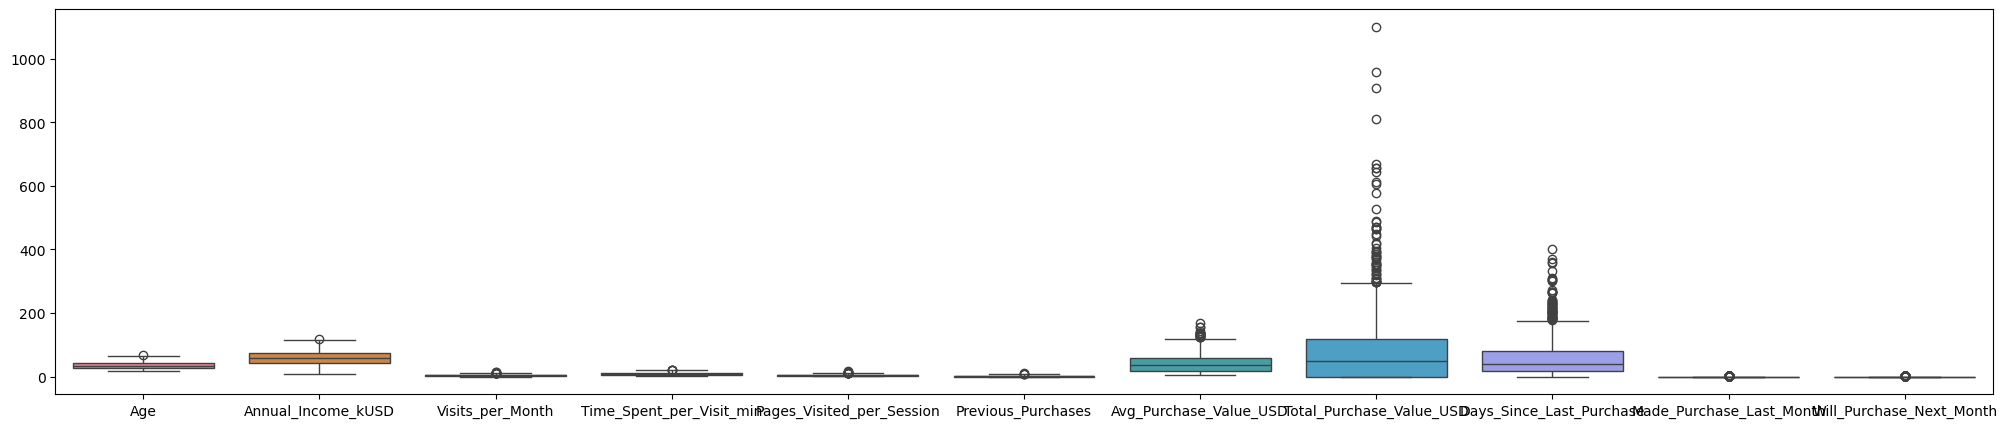

In [51]:
plt.figure(figsize=(25,5))
sns.boxplot(data=x_train[num_col])

In [52]:
x_train[obj_col].nunique()

Gender                2
Region                5
Platform              3
Product_Preference    6
dtype: int64

In [53]:
df.head()

,Age,Gender,Annual_Income_kUSD,Region,Platform,Product_Preference,Visits_per_Month,Time_Spent_per_Visit_min,Pages_Visited_per_Session,Previous_Purchases,Avg_Purchase_Value_USD,Total_Purchase_Value_USD,Days_Since_Last_Purchase,Made_Purchase_Last_Month,Will_Purchase_Next_Month,Next_Month_Spend_USD
0,40,Male,40.58,Central,Mobile,Apparel,5,6.0,5,1,35.665,42.43,0,0,0,0.0
1,33,Male,53.20,West,Mobile,Apparel,3,9.0,2,0,25.950,0.00,206,0,0,0.0
2,42,Female,73.70,West,Mobile,Home & Kitchen,3,13.9,2,0,71.060,13.92,15,0,0,0.0
3,51,Female,45.95,East,Mobile,Sports,3,1.0,4,1,35.810,91.43,149,0,0,0.0
4,32,Male,45.32,East,Mobile,Apparel,11,11.1,7,3,5.000,37.75,6,1,0,0.0


In [63]:
standard_col=['Age','Annual_Income_kUSD','Visits_per_Month','Time_Spent_per_Visit_min','Pages_Visited_per_Session','Previous_Purchases','Made_Purchase_Last_Month','Will_Purchase_Next_Month']

robust_col=['Avg_Purchase_Value_USD','Total_Purchase_Value_USD','Days_Since_Last_Purchase']

onehot_col=['Gender','Region','Platform','Product_Preference']

In [64]:
preprocessing=ColumnTransformer(
    transformers=[
        ('Standard_Scaler',StandardScaler(),standard_col),
        ('Onehot_encoder',OneHotEncoder(),onehot_col),
        ('Robust_encoder',RobustScaler(),robust_col)
    ],remainder='passthrough'
)

In [65]:
main_pipeline=Pipeline(
    steps=[
        ('preprocessing',preprocessing),
        ('model',KNeighborsRegressor(n_neighbors=15))
    ]
)

In [66]:
main_pipeline.fit(x_train,y_train)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Standard_Scaler', ...), ('Onehot_encoder', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [67]:
pred_ytrain=main_pipeline.predict(x_train)

In [68]:
pred_ytest=main_pipeline.predict(x_test)

In [72]:
# print(classification_report(y_train,pred_ytrain))
# Cannot use it for continuous values
# ValueError: continuous is not supported

In [78]:
print('R2 Score :',r2_score(y_train,pred_ytrain)*100)
print('MAE :',mean_absolute_error(y_train,pred_ytrain))
print('RMSE :',root_mean_squared_error(y_train,pred_ytrain))
print('MSE :',mean_squared_error(y_train,pred_ytrain))

R2 Score : 51.558684300703476
MAE : 4.317576666666667
RMSE : 15.28004380949217
MSE : 233.47973882


In [79]:
# For test data

print('R2 Score :',r2_score(y_test,pred_ytest)*100)
print('MAE :',mean_absolute_error(y_test,pred_ytest))
print('RMSE :',root_mean_squared_error(y_test,pred_ytest))
print('MSE :',mean_squared_error(y_test,pred_ytest))

R2 Score : 51.88250886853781
MAE : 5.21458
RMSE : 17.924612978062687
MSE : 321.2917504133333
